# Laboratorio 7: Spark MLlib
## Ejercicios 1 a 5

Este informe es reproducible: ejecuta `main7.py` con Spark 3.5 y las cinco bases de **Personas**. Las cifras, tablas y gráficas se calculan sobre el conjunto completo; únicamente las gráficas pueden usar una muestra si fuese necesario. El análisis es no ponderado: describe registros elegibles, no estimaciones oficiales de todos los trabajadores guatemaltecos. `FACTOR` se conserva para una posterior estimación poblacional ponderada.

### Alcance y decisiones

- Desarrollo: 2025T1–2025T4; prueba reservada: 2026T1 (no se usa en los ejercicios 1–5).
- La variable objetivo es `P05D01` (`salario_mensual`, quetzales): no se suma ningún otro ingreso ni se recorta/transforma el objetivo.
- Predictores de regresión: edad, antigüedad, horas semanales, nivel educativo, categoría ocupacional y dominio.
- Los faltantes o códigos textuales vacíos de las categorías se representan como `DESCONOCIDO`; el nivel educativo 0 se mantiene como una categoría válida.
- Renombre las cinco fuentes de modo que incluyan `2025T1`, `2025T2`, `2025T3`, `2025T4` y `2026T1` (por ejemplo, `Personas_2025T1.xlsx`).

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from main7 import run

DATA_DIR = Path('datos')       # cambie esta ruta si las bases se encuentran en otro lugar
OUTPUT_DIR = Path('salida_lab7')
resultados = run(str(DATA_DIR), str(OUTPUT_DIR))
# La ejecución también deja Parquet 2025/2026, JSON de resultados y el mejor Pipeline de regresión.

26/09/24 22:42:59 WARN Utils: Your hostname, vm resolves to a loopback address: 127.0.0.1; using 192.0.2.2 instead (on interface eth0)
26/09/24 22:42:59 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/24 22:42:59 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


26/09/24 22:43:11 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


26/09/24 22:44:10 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


26/09/24 22:44:40 WARN Instrumentation: [e3118e28] regParam is zero, which might cause numerical instability and overfitting.


26/09/24 22:44:41 WARN Instrumentation: [e3118e28] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.


## 1. Carga, armonización y calidad

Cada fuente se carga individualmente, se convierte a tipos explícitos y se etiqueta con `archivo_origen`, `periodo_archivo`, `anio_archivo` y `trimestre_calendario`. Los cuatro archivos de 2025 se unen con `unionByName`, no por posición: IV-2025 contiene 302 columnas frente a 270 en los demás, por lo que apilar por posición desalinearía variables. `TRIMESTRE` original se conserva como auditoría, pero no se usa para inferir el trimestre calendario.

Un valor ausente por no aplicar una pregunta representa que la pregunta no corresponde a la persona; una respuesta no registrada significa que sí correspondía pero no se obtuvo/registró. Son situaciones analíticamente distintas. Una persona en dos períodos es una observación longitudinal válida, no un duplicado; por ello se verifica la clave `(periodo_archivo, NUM_HOGAR, NUM_PERSONA)` sin aplicar `dropDuplicates()`.

In [2]:
e1 = resultados['ejercicio_1']
print('Esquema (columnas seleccionadas, tipos explícitos tras la conversión):')
for nombre, tipo in e1['esquema'].items():
    print(f'  {nombre}: {tipo}')
print('\nMuestra de 5 registros (I-2025):')
display(pd.DataFrame(e1['muestra_cinco_registros']))
print('\nRegistros por archivo, antes de filtros:')
display(pd.DataFrame(e1['registros_antes']))
print('Registros por archivo, después de filtros:')
display(pd.DataFrame(e1['registros_despues']))
print('Faltantes por variable seleccionada, antes de filtros (2025 completo):')
display(pd.DataFrame(e1['faltantes_antes_filtros']))
for periodo, auditoria in e1['auditoria_filtros'].items():
    print(f'\n{periodo}')
    display(pd.DataFrame(auditoria))
print('\nVerificación de unicidad de (periodo_archivo, NUM_HOGAR, NUM_PERSONA) en 2025:')
print(e1['duplicados_2025'])
print('Los Parquet preparados se guardaron separados para mantener 2026 como prueba final.')

Esquema (columnas seleccionadas, tipos explícitos tras la conversión):
  P05D01: string
  P02A03: string
  P05C07A: string
  P05C07B: string
  P05H01A: string
  P03A03A: string
  P05C16: string
  dominio: string
  OCUPADOS: string
  NUM_HOGAR: string
  NUM_PERSONA: string
  FACTOR: string
  ANIO: string
  TRIMESTRE: string
  archivo_origen: string
  periodo_archivo: string
  anio_archivo: int
  trimestre_calendario: int
  P05D01_n: double
  P02A03_n: double
  P05C07A_n: double
  P05C07B_n: double
  P05H01A_n: double
  OCUPADOS_n: double
  salario_mensual: double
  edad: double
  antiguedad_anios: double
  antiguedad_meses: double
  horas_semanales: double
  antiguedad: double
  nivel_educativo: string
  categoria_ocupacional: string

Muestra de 5 registros (I-2025):


,P05D01,P02A03,P05C07A,P05C07B,P05H01A,P03A03A,P05C16,dominio,OCUPADOS,NUM_HOGAR,...,P05H01A_n,OCUPADOS_n,salario_mensual,edad,antiguedad_anios,antiguedad_meses,horas_semanales,antiguedad,nivel_educativo,categoria_ocupacional
0,1633.0478889511683,65.0,12.0,2.0,165.0,1,4,Urbano,1.0,2377,...,165.0,1.0,1633.047889,65.0,12.0,2.0,165.0,12.166667,1,4
1,4365.614616804644,24.0,19.0,10.0,79.0,2,9,Urbano,1.0,5176,...,79.0,1.0,4365.614617,24.0,19.0,10.0,79.0,19.833333,2,9
2,8259.435997506067,15.0,15.0,6.0,102.0,3,3,Urbano,1.0,1072,...,102.0,1.0,8259.435998,15.0,15.0,6.0,102.0,15.500000,3,3
3,3319.225692859078,53.0,29.0,3.0,122.0,5,2,Urbano,1.0,3748,...,122.0,1.0,3319.225693,53.0,29.0,3.0,122.0,29.250000,5,2
4,3118.0531699744474,36.0,15.0,9.0,46.0,2,2,Urbano,2.0,4095,...,46.0,2.0,3118.053170,36.0,15.0,9.0,46.0,15.750000,2,2



Registros por archivo, antes de filtros:


,periodo,registros
0,2025T2,4000
1,2026T1,4000
2,2025T3,4000
3,2025T1,4000
4,2025T4,4000


Registros por archivo, después de filtros:


...


2025T1


,paso,antes,excluidos,despues
0,edad finita y >= 15,4000,68,3932
1,"ocupado y asalariado (P05C16 en 1,2,3,4)",3932,1735,2197
2,salario finito y > 0,2197,365,1832
3,componentes de antigüedad válidos,1832,0,1832
4,antigüedad <= edad,1832,111,1721
5,"horas en (0,168]",1721,114,1607



2025T4


,paso,antes,excluidos,despues
0,edad finita y >= 15,4000,74,3926
1,"ocupado y asalariado (P05C16 en 1,2,3,4)",3926,1755,2171
2,salario finito y > 0,2171,389,1782
3,componentes de antigüedad válidos,1782,0,1782
4,antigüedad <= edad,1782,123,1659
5,"horas en (0,168]",1659,87,1572



Verificación de unicidad de (periodo_archivo, NUM_HOGAR, NUM_PERSONA) en 2025:
{'claves_repetidas': 92, 'repeticiones_exactas': 0, 'claves_en_conflicto': 92}
Los Parquet preparados se guardaron separados para mantener 2026 como prueba final.


Los filtros se ejecutan, en el mismo orden y con conteo de exclusiones, para edad válida, condición ocupado/asalarial, salario positivo finito, componentes de antigüedad válidos, antigüedad no mayor que edad y horas en (0, 168]. Los registros finales no representan a todos los trabajadores del país: se restringen a asalariados ocupados de 15+ con salario registrado y los resultados no usan el factor de expansión.

**Respuestas:**

- **¿Por qué IV de 2025 no puede apilarse por posición de columnas con los otros archivos?** Porque tiene 302 columnas frente a 270 en los demás archivos; apilar por posición asignaría cada valor a la columna que ocupa ese mismo índice en cada archivo, no a la que tiene el mismo nombre, desalineando las variables. `unionByName` une por nombre de columna, evitando ese problema.
- **¿Qué diferencia existe entre un dato ausente porque la pregunta no corresponde y una respuesta no registrada?** El primero ocurre cuando la pregunta no aplica a la persona (por ejemplo, preguntas sobre antigüedad laboral a alguien no ocupado); el segundo ocurre cuando la pregunta sí correspondía pero no se obtuvo o no se registró la respuesta. Tratarlas igual mezclaría "no aplica" con "no se sabe", lo cual distorsiona los conteos de faltantes y su interpretación.
- **¿Por qué una persona observada en dos períodos no debe eliminarse como duplicado del conjunto longitudinal?** Porque la ENEIC tiene diseño longitudinal con rotación: una misma persona puede legítimamente aparecer en varios trimestres como observaciones distintas en el tiempo. Eliminarlas con `dropDuplicates()` perdería información real y reduciría artificialmente el tamaño de la muestra; por eso se audita la clave `(periodo_archivo, NUM_HOGAR, NUM_PERSONA)` en vez de deduplicar a ciegas.
- **¿Por qué el número de registros de la base filtrada no representa a todos los trabajadores del país?** Porque los filtros restringen la población a asalariados ocupados de 15 años o más con salario positivo registrado, excluyendo a no asalariados, no ocupados, menores de 15 y registros sin salario válido; además el análisis es no ponderado (no usa `FACTOR`), por lo que los conteos describen los registros elegibles de la muestra, no una estimación poblacional oficial.

## 2. Estadística descriptiva y exploración

Las medidas siguientes incluyen media, mediana, desviación estándar, mínimo, máximo y percentiles 25, 75 y 95. La comparación media–mediana permite diagnosticar asimetría: una media claramente mayor suele indicar cola derecha, que debe confirmarse con el histograma.

,n,media,desv_est,min,max,p25,mediana,p75,p95
salario_mensual,6389.0,3584.983918,1802.448513,182.90064,13758.634352,2270.768588,3264.140569,4564.456910,6912.993044
edad,6389.0,46.072468,16.467352,15.00000,74.000000,32.000000,46.000000,60.000000,72.000000
antiguedad,6389.0,14.210335,8.468179,0.00000,29.916667,6.833333,13.916667,21.166667,28.083333
horas_semanales,6389.0,84.546251,48.369853,1.00000,168.000000,42.000000,84.000000,126.000000,159.000000


,nivel_educativo,n,salario_mediano
0,2,1301,3269.503656
1,1,1281,3279.392827
2,3,1259,3312.693524
3,4,970,3225.820833
4,0,633,3215.003247
5,5,622,3259.506351
6,NaN,323,3268.921507


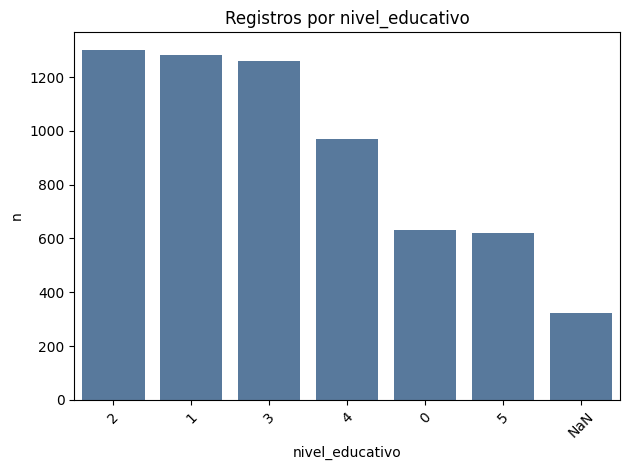

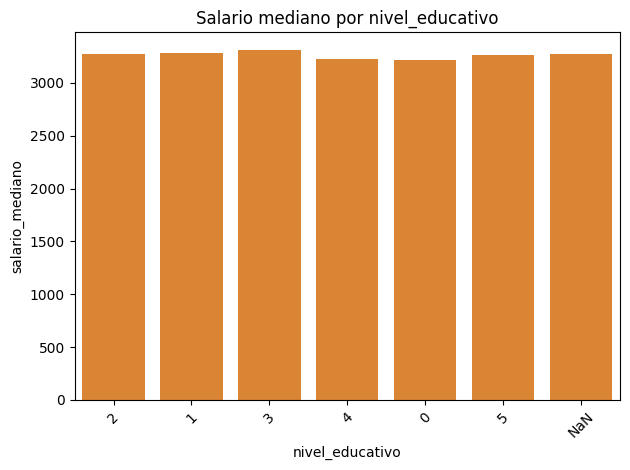

,categoria_ocupacional,n,salario_mediano
0,2,4070,3249.579498
1,4,784,3423.677704
2,3,779,3172.359376
3,1,756,3321.876634


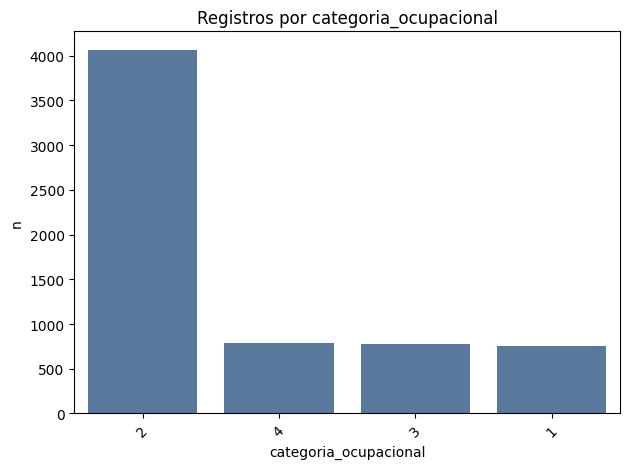

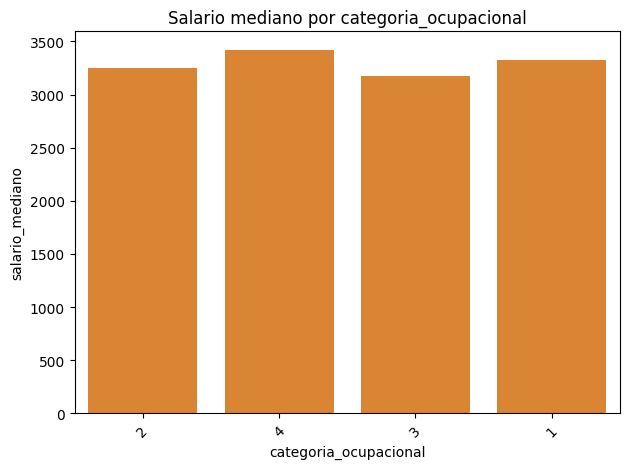

,dominio,n,salario_mediano
0,Urbano,3154,3296.296062
1,Rural,2293,3284.285600
2,urbano,639,3175.973497
3,NaN,303,3220.518346


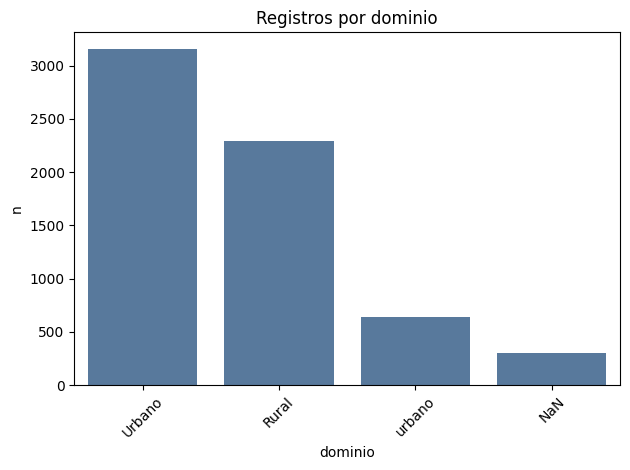

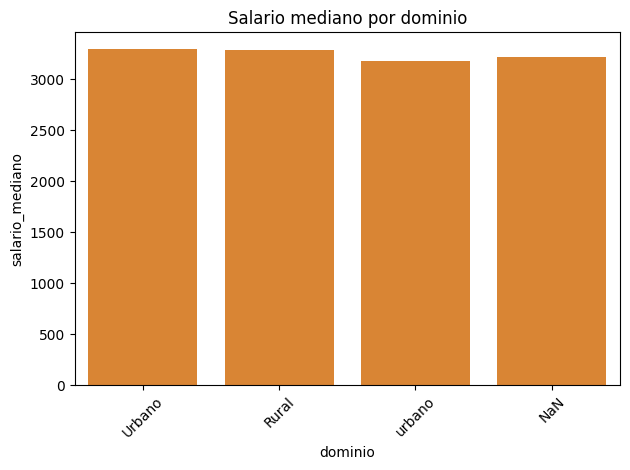

,periodo_archivo,n,salario_mediano
0,2025T1,1607,3327.794898
1,2025T2,1592,3304.856721
2,2025T3,1618,3234.367413
3,2025T4,1572,3220.518346


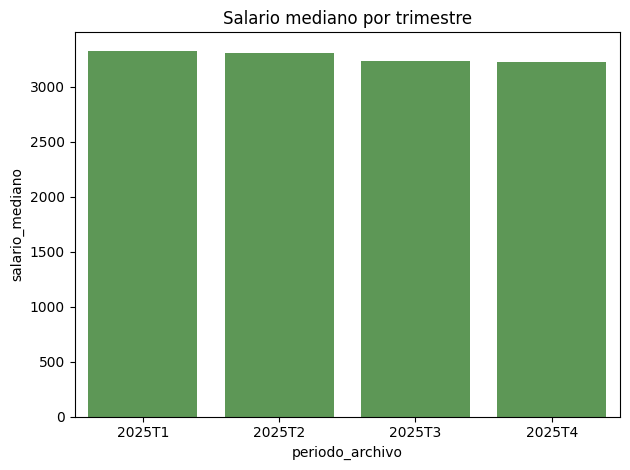

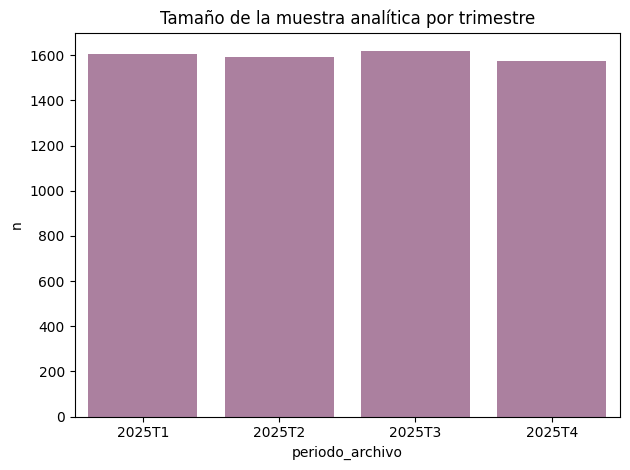

Media salarial: Q3,584.98; mediana: Q3,264.14; diferencia: Q320.84.
Interprete la dirección y magnitud de esta diferencia junto con la distribución; no elimine salarios extremos solo por ser extremos.


In [3]:
e2 = resultados['ejercicio_2']
display(pd.DataFrame(e2['descriptivos']).T)
for nombre, filas in e2['por_categoria'].items():
    tabla = pd.DataFrame(filas)
    display(tabla)
    sns.barplot(data=tabla, x=nombre, y='n', color='#4C78A8')
    plt.title(f'Registros por {nombre}'); plt.xticks(rotation=45); plt.tight_layout(); plt.show()
    sns.barplot(data=tabla, x=nombre, y='salario_mediano', color='#F58518')
    plt.title(f'Salario mediano por {nombre}'); plt.xticks(rotation=45); plt.tight_layout(); plt.show()
display(pd.DataFrame(e2['por_trimestre']))
sns.barplot(data=pd.DataFrame(e2['por_trimestre']), x='periodo_archivo', y='salario_mediano', color='#54A24B')
plt.title('Salario mediano por trimestre'); plt.tight_layout(); plt.show()
sns.barplot(data=pd.DataFrame(e2['por_trimestre']), x='periodo_archivo', y='n', color='#B279A2')
plt.title('Tamaño de la muestra analítica por trimestre'); plt.tight_layout(); plt.show()
sal = e2['descriptivos']['salario_mensual']
print(f"Media salarial: Q{sal['media']:,.2f}; mediana: Q{sal['mediana']:,.2f}; diferencia: Q{sal['media']-sal['mediana']:,.2f}.")
print('Interprete la dirección y magnitud de esta diferencia junto con la distribución; no elimine salarios extremos solo por ser extremos.')

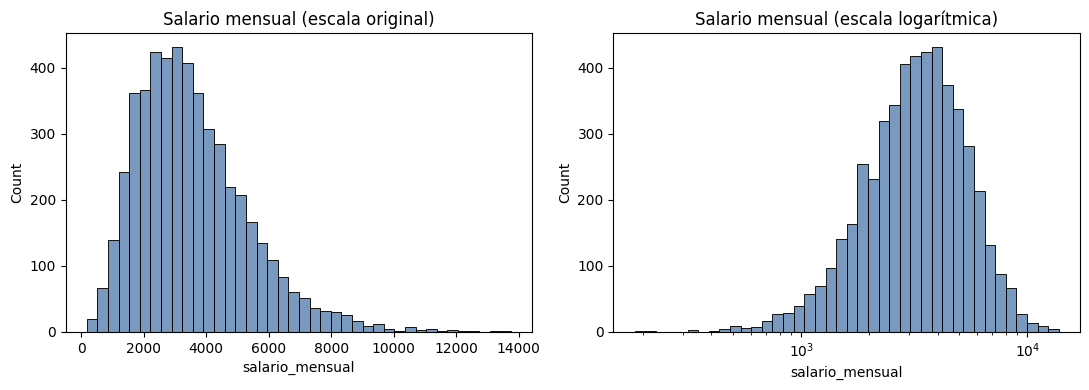

Compare esta forma con la diferencia media-mediana calculada arriba para diagnosticar simetría/asimetría.


In [4]:
# Histograma de salario (muestra de hasta 5,000 registros solo para graficar; los descriptivos ya son sobre el total)
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()
train25 = spark.read.parquet(str(OUTPUT_DIR / 'personas_2025_preparado.parquet'))
muestra_salario = train25.select('salario_mensual').sample(fraction=min(1.0, 5000 / train25.count()), seed=2026).toPandas()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(muestra_salario['salario_mensual'], bins=40, ax=axes[0], color='#4C78A8')
axes[0].set_title('Salario mensual (escala original)')
sns.histplot(muestra_salario['salario_mensual'], bins=40, ax=axes[1], color='#4C78A8', log_scale=True)
axes[1].set_title('Salario mensual (escala logarítmica)')
plt.tight_layout(); plt.show()
print('Compare esta forma con la diferencia media-mediana calculada arriba para diagnosticar simetría/asimetría.')

## 3. Relaciones entre variables numéricas

La matriz se calcula con `VectorAssembler` y `pyspark.ml.stat.Correlation.corr(method='pearson')` sobre todos los registros elegibles de 2025. La mayor correlación absoluta fuera de la diagonal identifica la asociación lineal más fuerte con salario; no prueba causalidad. La celda también permite revisar la relación edad–antigüedad.

,salario_mensual,edad,antiguedad,horas_semanales
salario_mensual,1.000,-0.004,-0.010,-0.005
edad,-0.004,1.000,0.122,0.004
antiguedad,-0.010,0.122,1.000,-0.011
horas_semanales,-0.005,0.004,-0.011,1.000


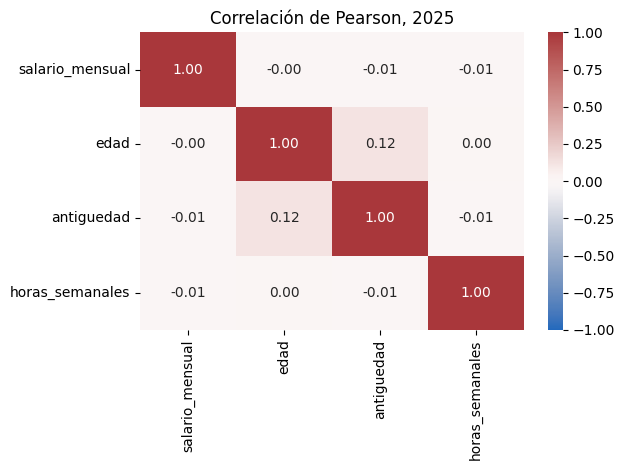

Correlaciones de salario:


antiguedad        -0.010313
horas_semanales   -0.005439
edad              -0.004038
Name: salario_mensual, dtype: float64

Correlación edad–antigüedad: 0.122


In [5]:
e3 = resultados['ejercicio_3']
corr = pd.DataFrame(e3['matriz'], index=e3['etiquetas'], columns=e3['etiquetas'])
display(corr.round(3))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1)
plt.title('Correlación de Pearson, 2025'); plt.tight_layout(); plt.show()
print('Correlaciones de salario:')
display(corr['salario_mensual'].drop('salario_mensual').sort_values(key=lambda s: s.abs(), ascending=False))
print('Correlación edad–antigüedad:', round(corr.loc['edad', 'antiguedad'], 3))

## 4. Segmentación con KMeans

KMeans usa edad, antigüedad y horas habituales, estandarizadas con `StandardScaler`. Se deja fuera el salario para que los grupos sean perfiles de condiciones personales/laborales y no una segmentación dominada por el objetivo. Se evalúan K=2, 3, 4 y 5 mediante silueta (mayor es mejor) y costo WSSSE; la descripción de cada grupo se fundamenta en sus medias, tamaño y salario mediano/medio como resultado descriptivo.

,k,silhouette,wssse
0,2,0.376491,14281.274278
1,3,0.389297,11115.024030
2,4,0.423569,8790.747256
3,5,0.434497,7216.740448


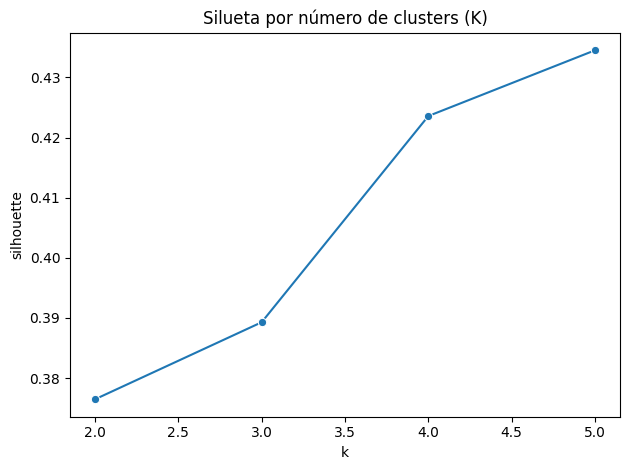

K seleccionado por mayor silueta: 5


,cluster,n,media_edad,media_antiguedad,media_horas_semanales,media_salario_mensual
0,0,1171,30.179334,9.039710,128.767720,3569.675404
1,1,1283,52.448948,22.577812,41.468433,3581.640993
2,2,1225,30.941224,10.178095,40.517551,3630.384342
3,3,1309,52.029030,22.250828,128.310160,3573.010642
4,4,1401,61.182013,6.882584,84.641685,3572.330628



Medias generales (referencia para comparar cada cluster):
media_edad                 46.07
media_antiguedad           14.21
media_horas_semanales      84.55
media_salario_mensual    3584.98
dtype: float64

Desviación de cada cluster respecto a la media general (positivo = por encima del promedio):


,cluster,n,media_edad,media_antiguedad,media_horas_semanales,media_salario_mensual
0,0,1171,-15.89,-5.17,44.22,-15.31
1,1,1283,6.38,8.37,-43.08,-3.34
2,2,1225,-15.13,-4.03,-44.03,45.40
3,3,1309,5.96,8.04,43.76,-11.97
4,4,1401,15.11,-7.33,0.10,-12.65


Use esta tabla de desviaciones para describir cada cluster (p. ej. "cluster con edad y antigüedad por encima del promedio, horas similares al promedio").


In [6]:
e4 = resultados['ejercicio_4']
display(pd.DataFrame(e4['pruebas']))
sns.lineplot(data=pd.DataFrame(e4['pruebas']), x='k', y='silhouette', marker='o')
plt.title('Silueta por número de clusters (K)'); plt.tight_layout(); plt.show()
print('K seleccionado por mayor silueta:', e4['mejor']['k'])
perfiles = pd.DataFrame(e4['perfiles'])
display(perfiles)
medias_generales = perfiles[['media_edad', 'media_antiguedad', 'media_horas_semanales', 'media_salario_mensual']].mul(perfiles['n'], axis=0).sum() / perfiles['n'].sum()
print('\nMedias generales (referencia para comparar cada cluster):')
print(medias_generales.round(2))
print('\nDesviación de cada cluster respecto a la media general (positivo = por encima del promedio):')
desviacion = perfiles[['media_edad', 'media_antiguedad', 'media_horas_semanales', 'media_salario_mensual']].sub(medias_generales)
display(pd.concat([perfiles[['cluster', 'n']], desviacion.round(2)], axis=1))
print('Use esta tabla de desviaciones para describir cada cluster (p. ej. "cluster con edad y antigüedad por encima del promedio, horas similares al promedio").')

**Sobre incluir salario en el clustering:** se decidió dejarlo fuera de las variables de segmentación (edad, antigüedad, horas) porque el objetivo de esta segmentación es describir perfiles de condiciones personales/laborales, no una partición dominada por el propio salario. Incluirlo tendería a producir clusters que simplemente separan por rango salarial en vez de por características laborales; en su lugar, el salario medio/mediano de cada cluster se reporta como resultado descriptivo posterior a la segmentación, lo que permite ver cómo se relacionan los perfiles laborales con el salario sin que el algoritmo optimice directamente sobre él.

## 5. Pipeline de regresión lineal

La validación es una partición 80/20 de 2025 con semilla 2026. Cada `Pipeline` ajusta `StringIndexer`, `OneHotEncoder`, ensamblado de los seis predictores, `StandardScaler` y `LinearRegression` **solo** con entrenamiento. Se comparan tres configuraciones (`regParam`, `elasticNetParam`) y se elige la de menor RMSE de validación. El referente predice siempre la media de entrenamiento/validación según la tabla, por lo que un modelo útil debe disminuir MAE/RMSE e incrementar R² respecto de ese referente.

El mejor pipeline se guarda en `salida_lab7/mejor_regresion_lineal`. La prueba 2026 permanece intacta para los ejercicios 6–8.

In [7]:
e5 = resultados['ejercicio_5']
display(pd.DataFrame(e5['configuraciones']).sort_values('rmse'))
display(pd.DataFrame([e5['referencia_media']], index=['referencia: media']))
print('Mejor configuración:', e5['mejor'])
print('Tamaños de partición:', e5['particion'])
print('Conclusión: compare RMSE, MAE y R² de la mejor fila contra el referente. R² cercano a 1 es mejor; un valor negativo indica desempeño peor que predecir la media.')

,regParam,elasticNetParam,mae,rmse,r2
2,0.1,0.5,1445.003217,1858.014519,-0.00781
1,0.1,0.0,1445.013545,1858.023644,-0.00782
0,0.0,0.0,1445.013951,1858.024035,-0.00782


,mae,rmse,r2
referencia: media,1447.09192,1850.801546,2.220446e-16


Mejor configuración: {'regParam': 0.1, 'elasticNetParam': 0.5, 'mae': 1445.0032172507035, 'rmse': 1858.0145193302722, 'r2': -0.00780962004979191}
Tamaños de partición: {'entrenamiento': 5092, 'validacion': 1297}
Conclusión: compare RMSE, MAE y R² de la mejor fila contra el referente. R² cercano a 1 es mejor; un valor negativo indica desempeño peor que predecir la media.


## Conclusión del avance

El notebook deja evidencia de trazabilidad, filtros, descriptivos, asociación lineal, perfiles de clustering y selección de regresión. Al ejecutar las celdas con las fuentes oficiales, las tablas impresas permiten redactar conclusiones con valores concretos sin inventar resultados. No se deben interpretar las correlaciones, clusters ni predicciones como efectos causales o recomendaciones salariales.